In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
from numpy.ma.core import negative

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 28, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 10})
plt.rcParams.update({"axes.prop_cycle": plt.cycler("color", ["royalblue", "tomato", "forestgreen", "darkgoldenrod", "darkorchid"])})

In [56]:
exp_list = ["glori","m6ace","miclip2","sac",]
exp_dict = {}
exp_path = "/extdata3/baeklab/Jungmin/RNAmod/valid.new/cmp/{exp}.txt"
for exp in exp_list:
    df = pd.read_csv(exp_path.format(exp=exp), sep="\t")
    df["genome_id"] = df["chr"] + ":" + df["str"].astype(str) + ":" + df["pos"].astype(str)
    df["m6a"] = df["m6a"] & (df["qval"] < 0.00001)
    exp_dict[exp] = df
for exp in ["m6ace","miclip2","sac"]:
    df = exp_dict[exp]
    df = df.rename(columns={"m6a": f"label_{exp}", "depth": f"depth_{exp}", "qval": f"q_{exp}"})
    df = df[["genome_id", f"label_{exp}", f"depth_{exp}", f"q_{exp}"]].copy()
    exp_dict[exp] = df
for exp in ["glori"]:
    df = exp_dict[exp]
    df = df.rename(columns={"m6a": f"label_{exp}", "depth": f"depth_{exp}", "dom": f"dom_{exp}", "qval": f"q_{exp}"})
    df = df[["genome_id", f"label_{exp}", f"depth_{exp}", f"dom_{exp}", f"q_{exp}"]].copy()
    exp_dict[exp] = df
for exp in exp_list:
    df = exp_dict[exp]
    df = df.set_index("genome_id", drop=True)
    exp_dict[exp] = df

label_df = pd.concat(exp_dict.values(), axis=1).reset_index()
label_df["label_glori_alt"] = label_df["dom_glori"] >= 0.1
print(label_df)


                genome_id label_glori  depth_glori  dom_glori   q_glori  \
0            chr1:+:14120       False          1.0        NaN  0.129512   
1            chr1:+:63441       False          1.0        NaN  0.137144   
2           chr1:+:183817       False          3.0        NaN  0.016432   
3           chr1:+:184515       False          2.0        NaN  0.381221   
4           chr1:+:184761       False          1.0        NaN  0.194671   
...                   ...         ...          ...        ...       ...   
12206697  chrY:-:57015831         NaN          NaN        NaN       NaN   
12206698  chrY:-:57015855         NaN          NaN        NaN       NaN   
12206699  chrY:-:57015886         NaN          NaN        NaN       NaN   
12206700  chrY:-:57015896         NaN          NaN        NaN       NaN   
12206701  chrY:-:57015923         NaN          NaN        NaN       NaN   

         label_m6ace  depth_m6ace  q_m6ace label_miclip2  depth_miclip2  \
0                NaN    

In [57]:
benchmark_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/poster/benchmark_df.pkl")

In [58]:
benchmark_df = benchmark_df.merge(label_df, on="genome_id", how="inner")
print(benchmark_df)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
1         chr10:+:1000683  0.016154  0.013023      501.0     0.002024   
2         chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
3         chr10:+:1000694 -0.000000  0.006251      509.0     0.006061   
4         chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
...                   ...       ...       ...        ...          ...   
10830114   chrY:-:5337902       NaN       NaN        NaN     0.000000   
10830115   chrY:-:5337903       NaN       NaN        NaN     0.000000   
10830116   chrY:-:5337907       NaN       NaN        NaN          NaN   
10830117   chrY:-:5337909       NaN       NaN        NaN          NaN   
10830118   chrY:-:5337910       NaN       NaN        NaN          NaN   

          count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
0                473.0          NaN         Na

In [60]:
benchmark_df["label_sum"] = benchmark_df[["label_glori", "label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)
benchmark_df["label_alt"] = benchmark_df[["label_glori_alt", "label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)
benchmark_df["label_aux"] = benchmark_df[["label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)

In [61]:
benchmark_df["positive"] = (benchmark_df["label_alt"] >= 3)
print(benchmark_df["positive"].sum())

27149


In [62]:
print(benchmark_df["label_glori_alt"].sum(), benchmark_df["label_m6ace"].sum(), benchmark_df["label_miclip2"].sum(), benchmark_df["label_sac"].sum())

print(benchmark_df["positive"].value_counts())

235008 121238 63595 203957
positive
False    10802970
True        27149
Name: count, dtype: int64


In [63]:
positive_df = benchmark_df[benchmark_df["positive"]]
print(positive_df)

                  genome_id      pm6a       dom  count_all  pred_dorado  \
973       chr10:+:100363097  0.860140  0.181485     3825.0     0.176799   
1070      chr10:+:100363423  0.767349  0.257288     4035.0     0.167568   
1342      chr10:+:100364512  1.595091  0.354627     3040.0     0.336074   
1355      chr10:+:100364569  0.875707  0.206898     3101.0     0.214758   
2763      chr10:+:100548246  1.740800  0.715153      268.0     0.670782   
...                     ...       ...       ...        ...          ...   
10819894    chrX:-:77683655  1.696218  0.361291       29.0     0.259259   
10820047    chrX:-:77684181  1.584059  0.491815       24.0     0.478261   
10822821    chrX:-:80676800  2.616605  0.674221       46.0     0.636364   
10827143    chrX:-:93672585  2.849546  1.000000        4.0     1.000000   
10827206    chrX:-:93672890  2.258130  0.872796        4.0     0.750000   

          count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
973             3767.0

In [64]:
valid_gene_list = np.unique(np.concatenate(positive_df["gene_id"].dropna().values))
print(valid_gene_list)

['A1BG' 'A1BG-AS1' 'AADAT' ... 'ZYG11B' 'ZZEF1' 'ZZZ3']


In [65]:
benchmark_df["gene_length"] = benchmark_df["gene_id"].apply(lambda x: len(x))
benchmark_df_single_gene = benchmark_df[benchmark_df["gene_length"]==1].copy()
benchmark_df_multi_gene = benchmark_df[benchmark_df["gene_length"]>1].copy()
print(len(benchmark_df_single_gene), len(benchmark_df_multi_gene))

10578181 251938


In [66]:
benchmark_df_single_gene["gene_id_2"] = benchmark_df_single_gene["gene_id"].apply(lambda x: x[0])
benchmark_df_single_gene["valid_gene"] = benchmark_df_single_gene["gene_id_2"].isin(valid_gene_list)
benchmark_df_single_gene = benchmark_df_single_gene.drop(columns=["gene_id_2"])

In [67]:
benchmark_df_multi_gene = benchmark_df_multi_gene.explode("gene_id", ignore_index=True)
benchmark_df_multi_gene["valid_gene"] = benchmark_df_multi_gene["gene_id"].isin(valid_gene_list)
valid_series = benchmark_df_multi_gene.groupby("genome_id").agg({"valid_gene": "sum"})
benchmark_df_multi_gene = benchmark_df_multi_gene.drop(columns=["valid_gene"])
benchmark_df_multi_gene = benchmark_df_multi_gene.merge(valid_series, on="genome_id", how="inner")
print(benchmark_df_multi_gene)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0       chr10:+:102120660  0.000000  0.000000        2.0         0.00   
1       chr10:+:102120660  0.000000  0.000000        2.0         0.00   
2       chr10:+:102120693  0.000000  0.000000        2.0         0.00   
3       chr10:+:102120693  0.000000  0.000000        2.0         0.00   
4       chr10:+:102120787  0.000000  0.000000        2.0         0.00   
...                   ...       ...       ...        ...          ...   
510475    chrX:-:72572834  0.257465  0.163126       17.0         0.25   
510476    chrX:-:72572837  0.000000  0.000000       19.0         0.00   
510477    chrX:-:72572837  0.000000  0.000000       19.0         0.00   
510478    chrX:-:72572840  0.000000  0.000000       12.0         0.00   
510479    chrX:-:72572840  0.000000  0.000000       12.0         0.00   

        count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
0                2.0          NaN         NaN   

In [68]:
final_benchmark_df = pd.concat([benchmark_df_single_gene, benchmark_df_multi_gene])

In [77]:
final_benchmark_df["negative"] = ~(final_benchmark_df["q_miclip2"]<=0.01) & ~(final_benchmark_df["q_m6ace"]<=0.01) & ~(final_benchmark_df["q_sac"]<=0.01) & ~(final_benchmark_df["q_glori"]<=0.01) & (final_benchmark_df["valid_gene"]>0)
print(final_benchmark_df["negative"].sum())

5223417


In [78]:
final_benchmark_df = final_benchmark_df[(final_benchmark_df["positive"]) | (final_benchmark_df["negative"])].copy()
final_benchmark_df = final_benchmark_df[final_benchmark_df["depth"] >= 20]
final_benchmark_df["label"] = final_benchmark_df["positive"]
print(final_benchmark_df)

              genome_id      pm6a       dom  count_all  pred_dorado  \
0       chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
2       chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
4       chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
5       chr10:+:1000704  0.024072  0.017848      504.0     0.047312   
6       chr10:+:1000713 -0.000000  0.001570      505.0     0.006085   
...                 ...       ...       ...        ...          ...   
510469  chrX:-:72572825  0.000000  0.000000       26.0     0.000000   
510476  chrX:-:72572837  0.000000  0.000000       19.0     0.000000   
510477  chrX:-:72572837  0.000000  0.000000       19.0     0.000000   
510478  chrX:-:72572840  0.000000  0.000000       12.0     0.000000   
510479  chrX:-:72572840  0.000000  0.000000       12.0     0.000000   

        count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
0              473.0          NaN         NaN           NaN    519  ... 

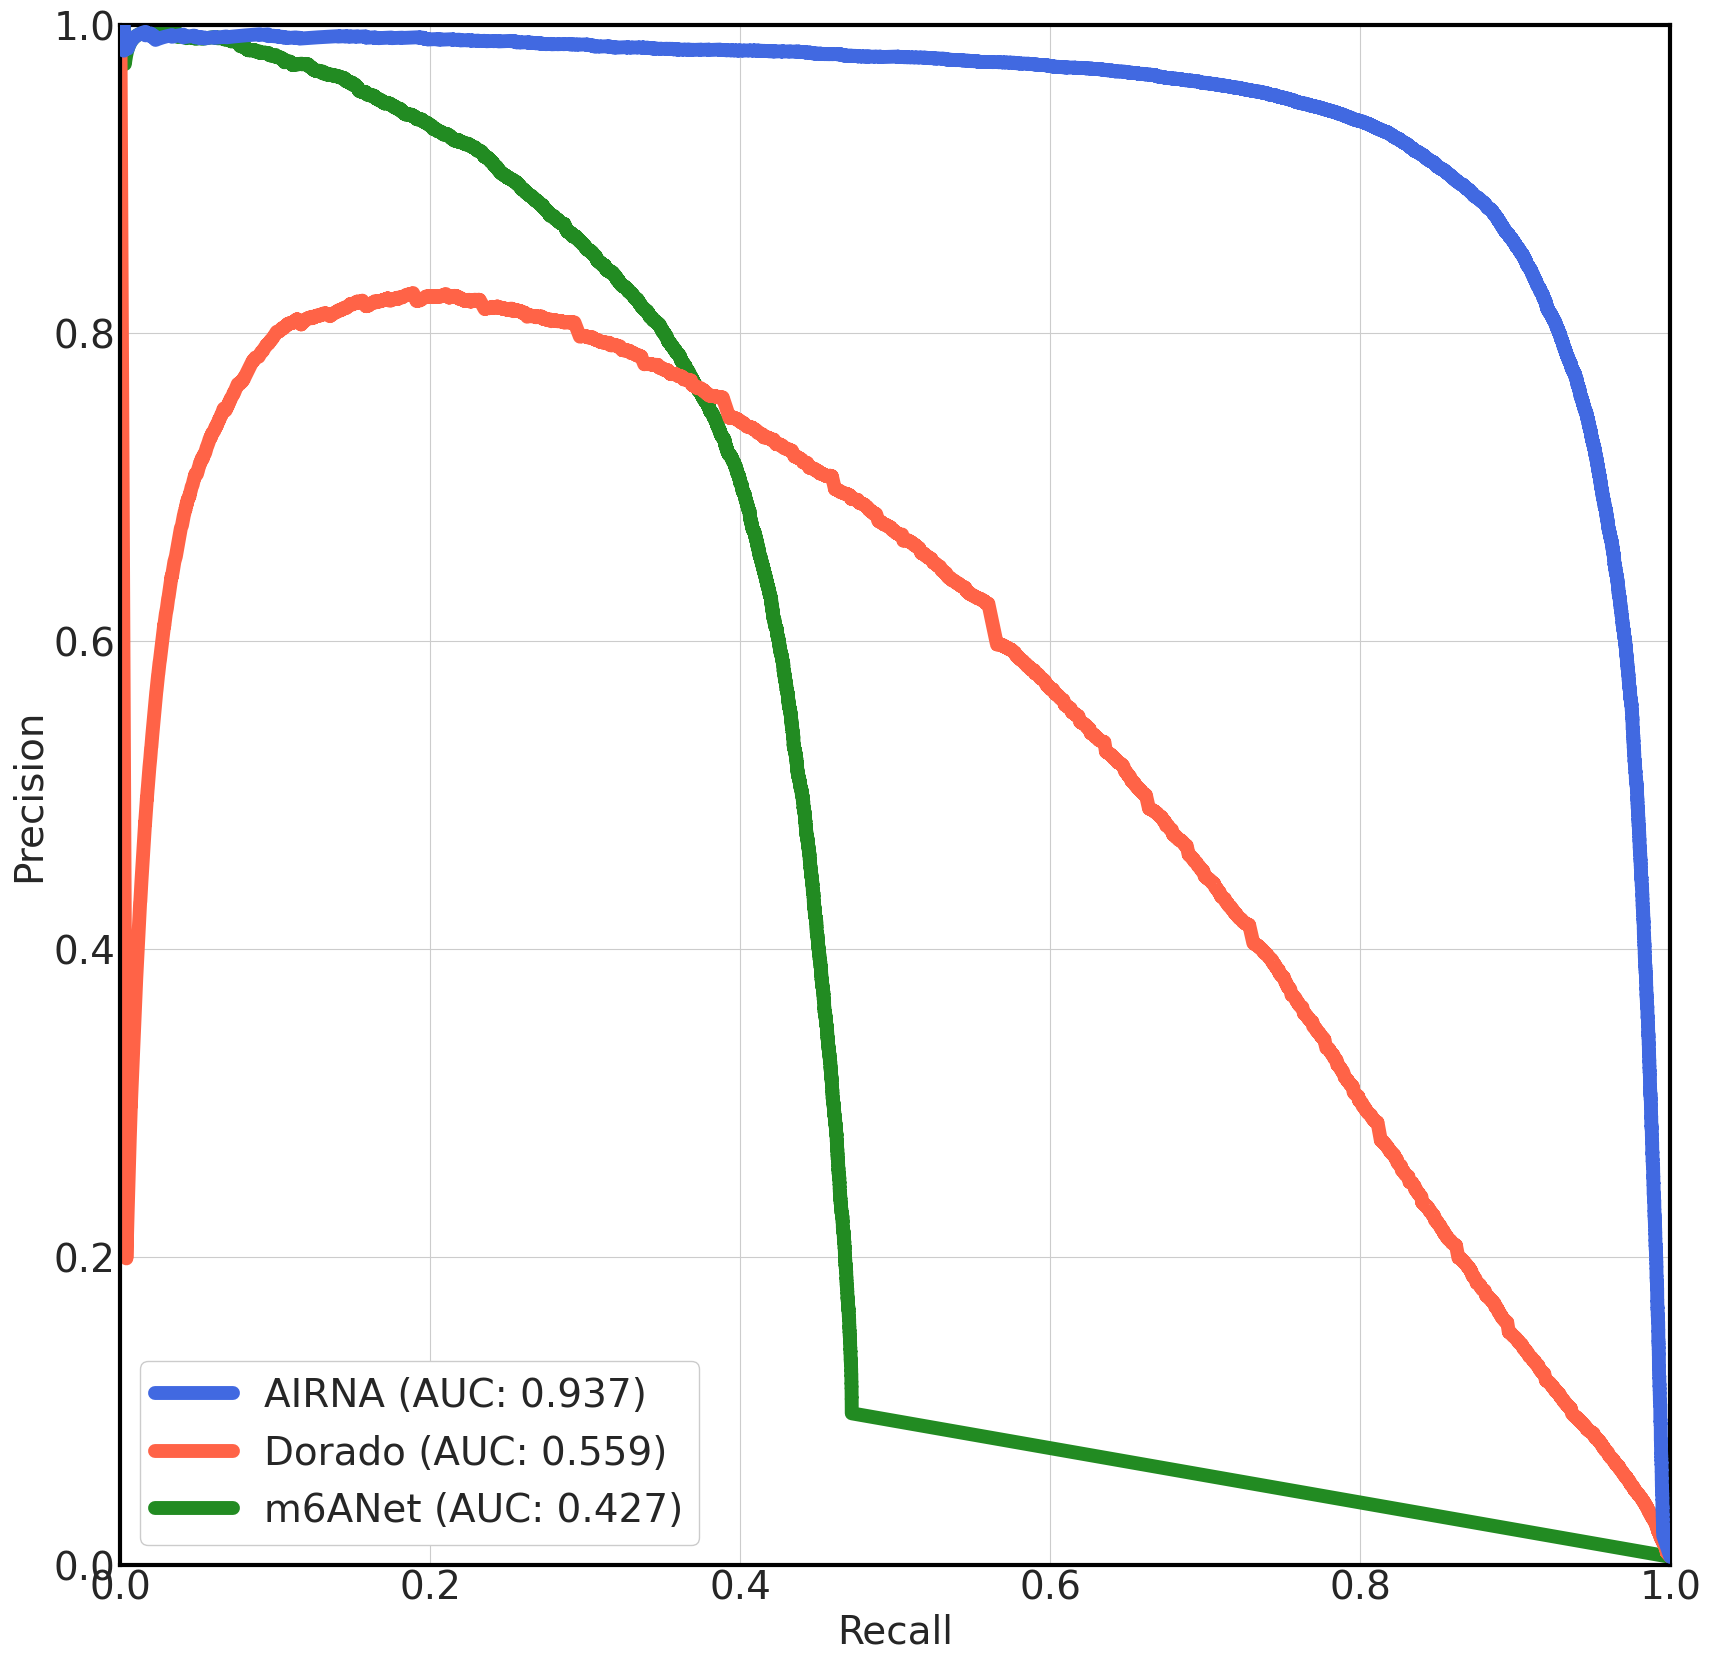

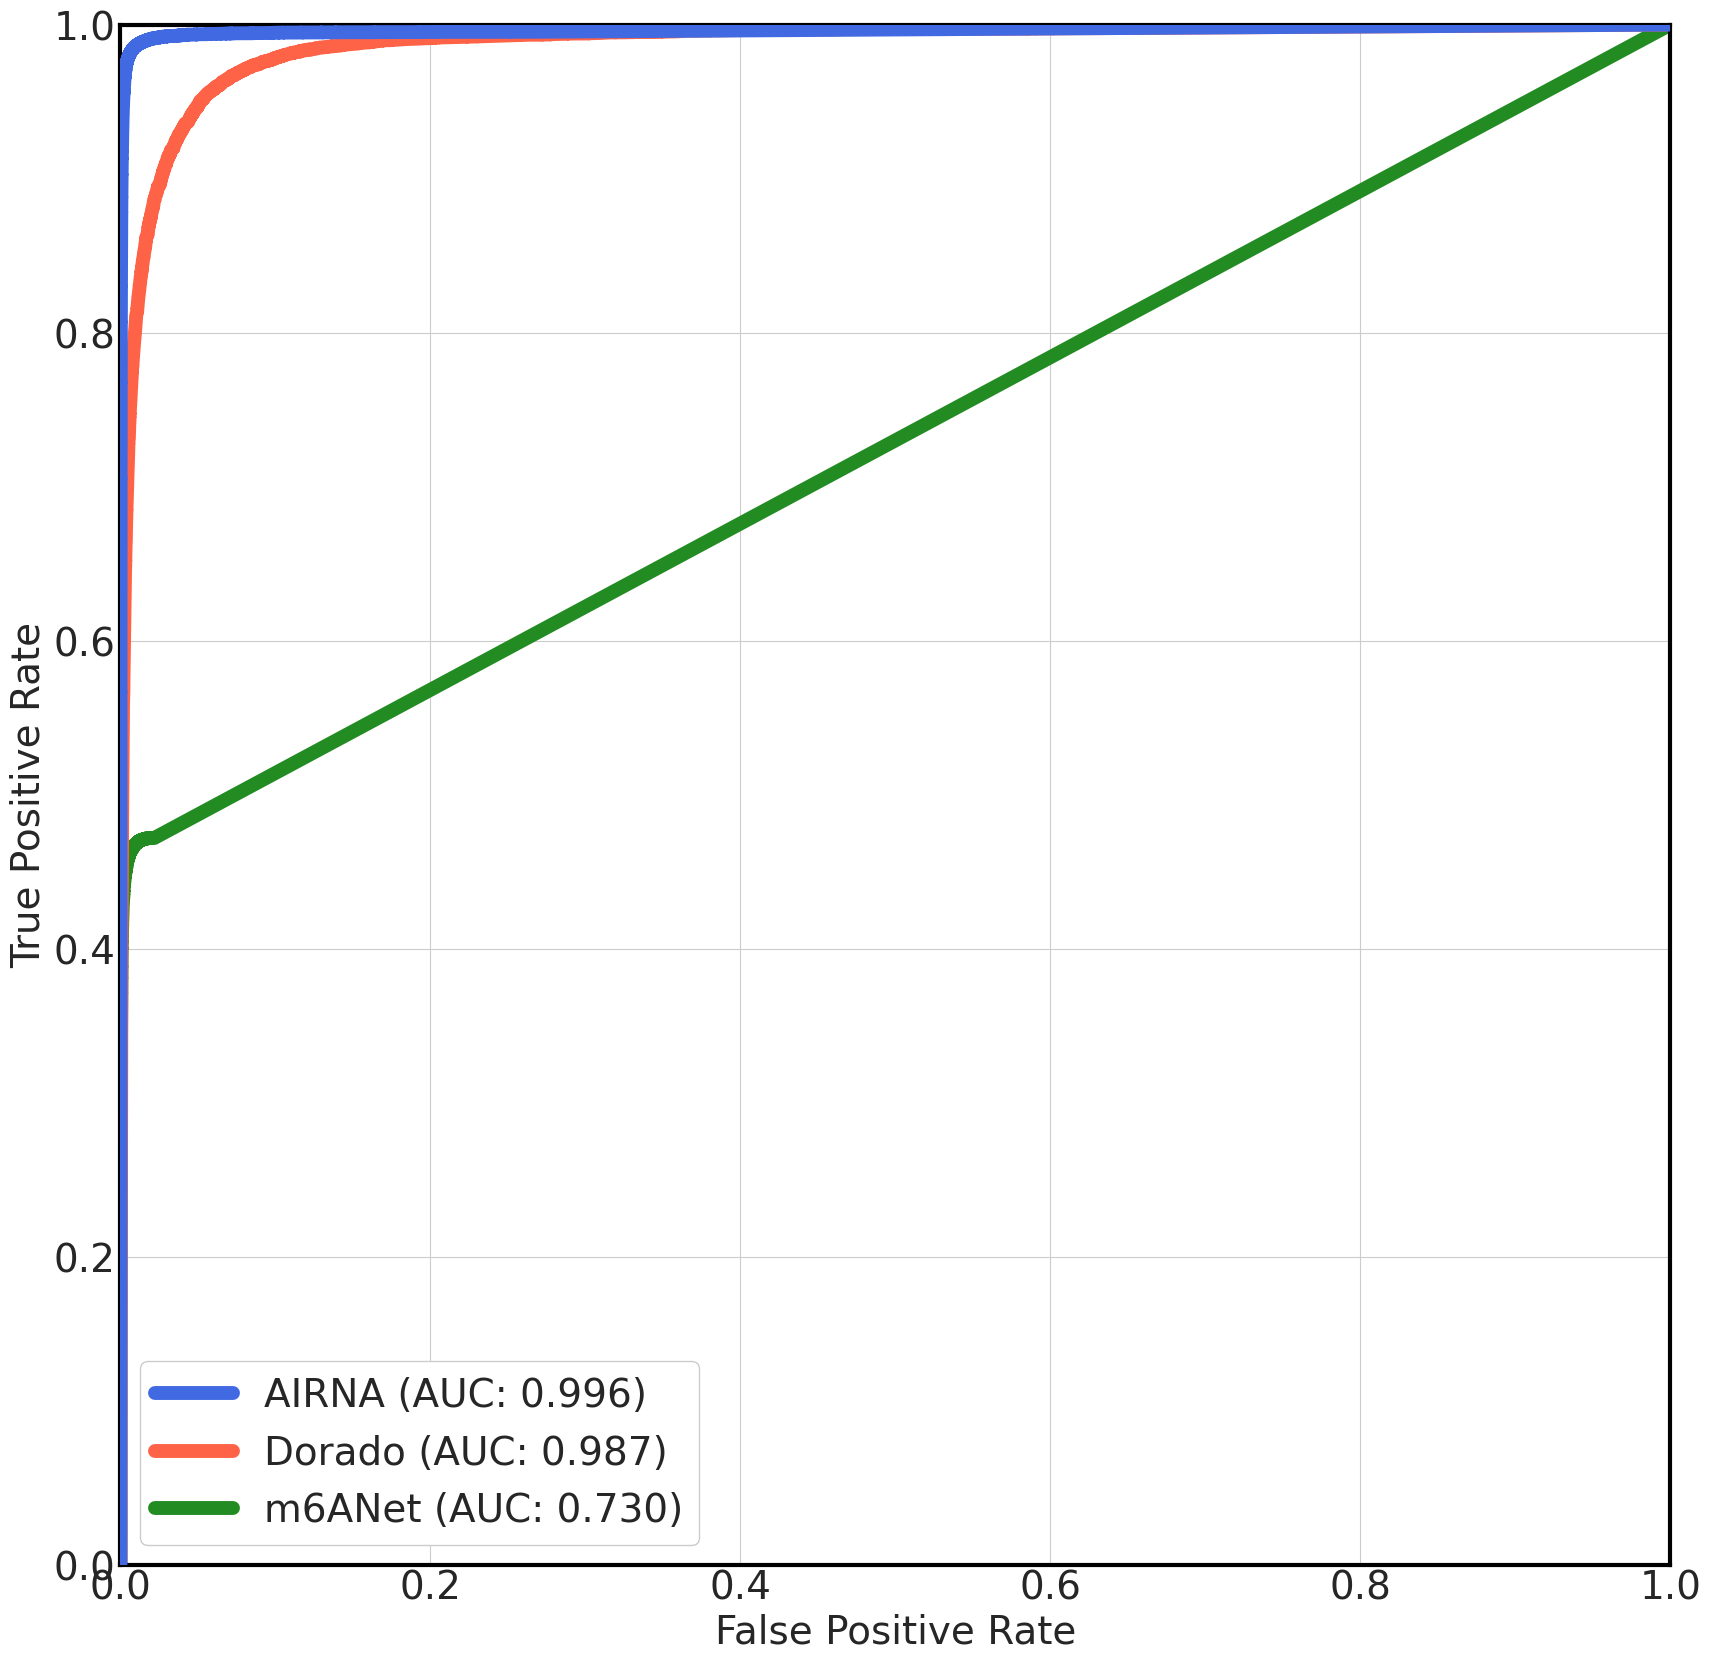

In [71]:
selected_df = final_benchmark_df.fillna(0).copy()


## Plot PR
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_roc.pdf", format="pdf")
plt.show()


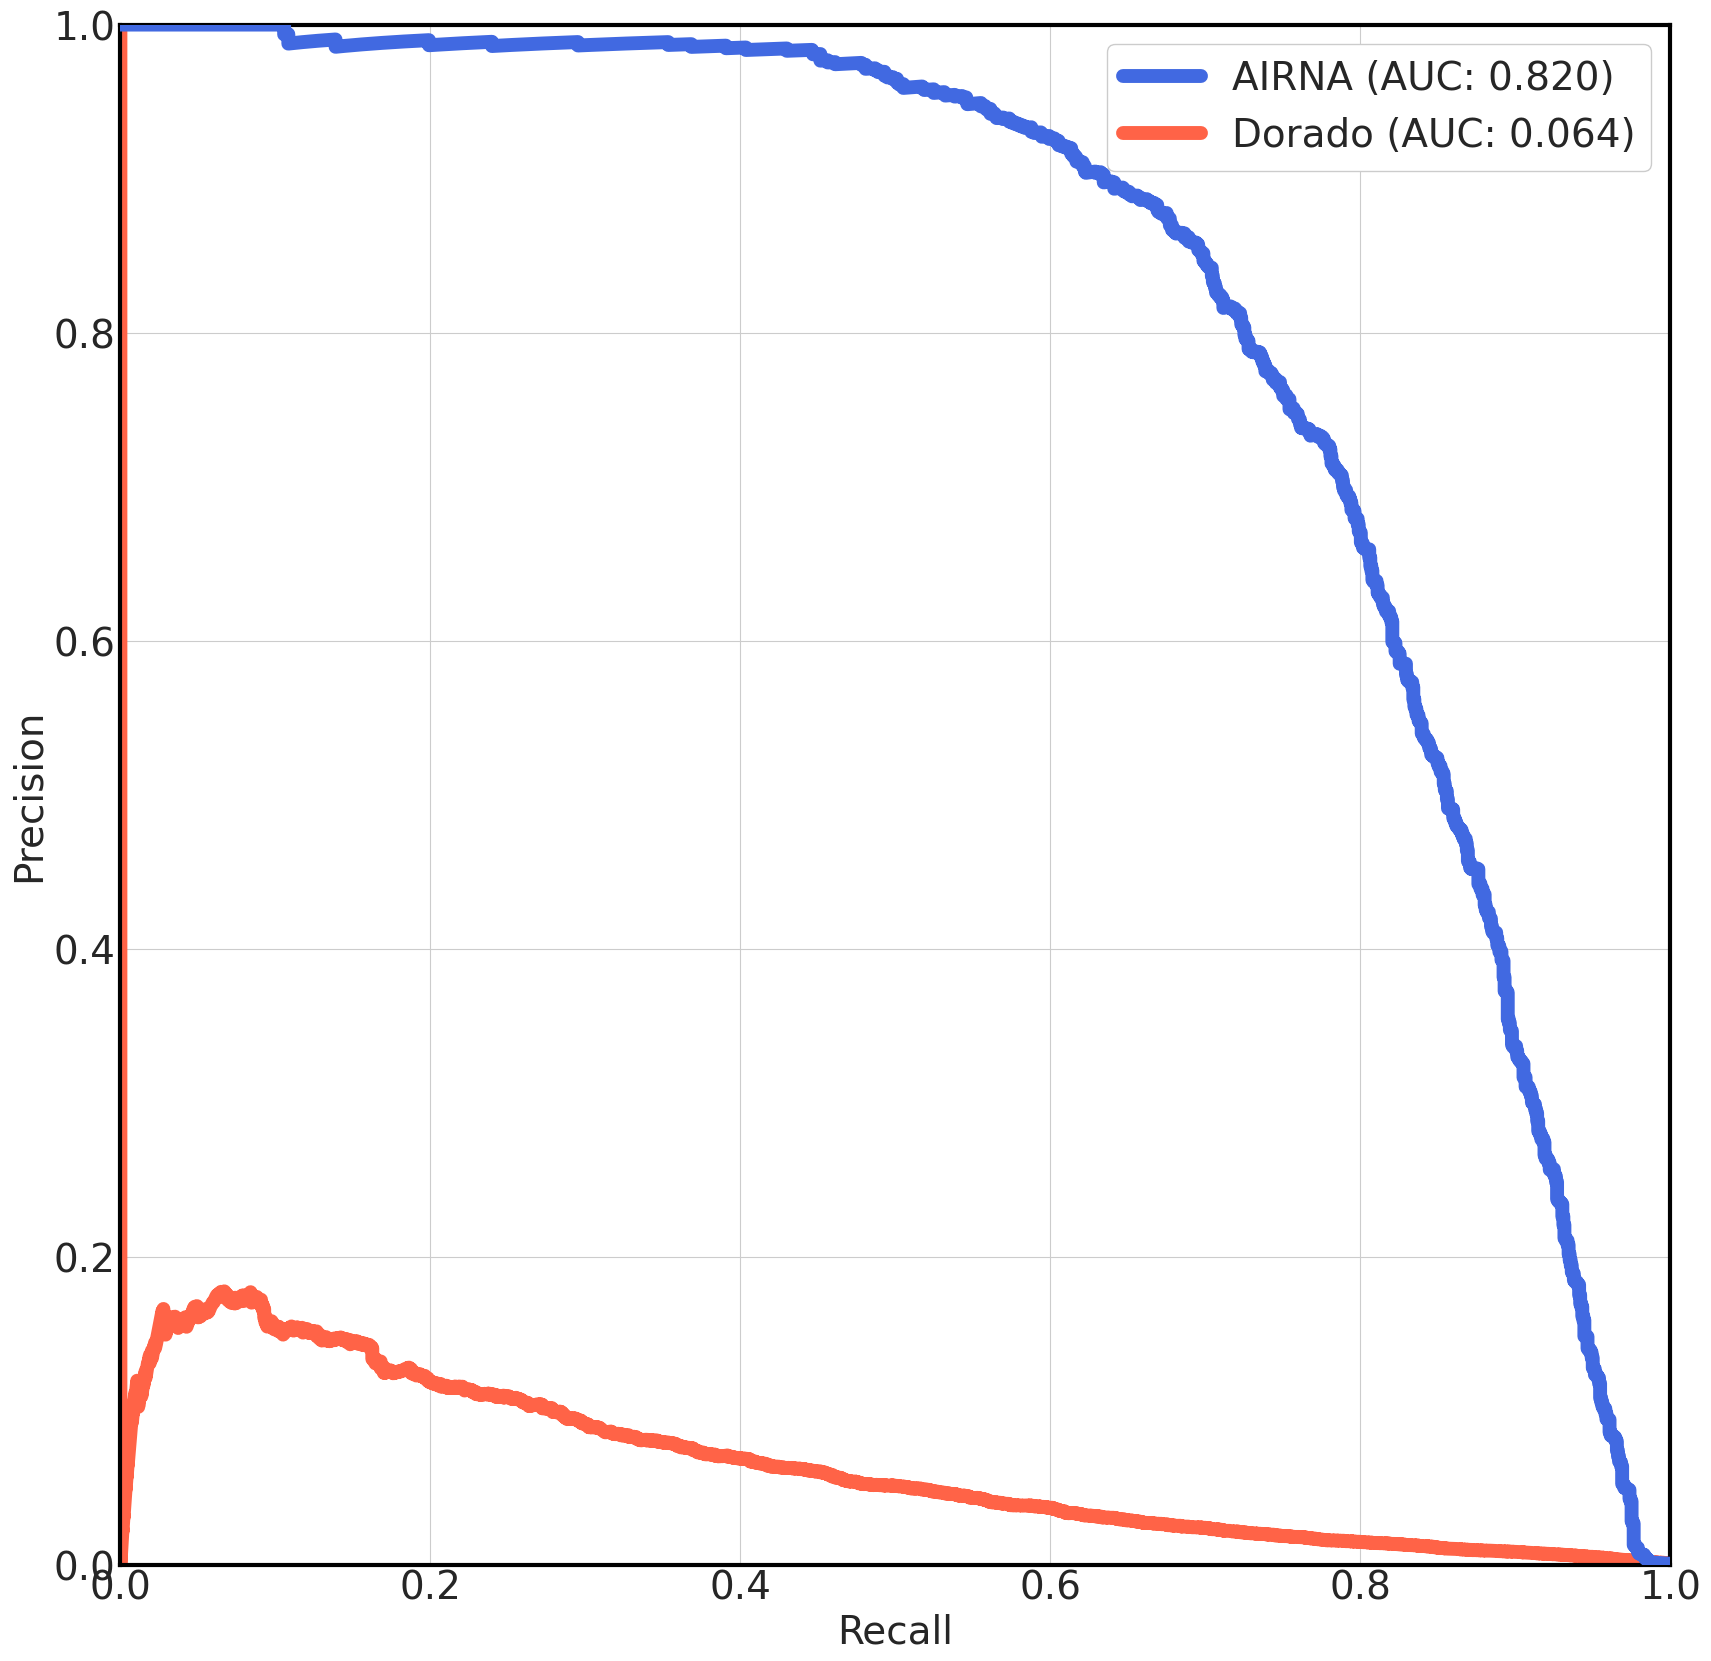

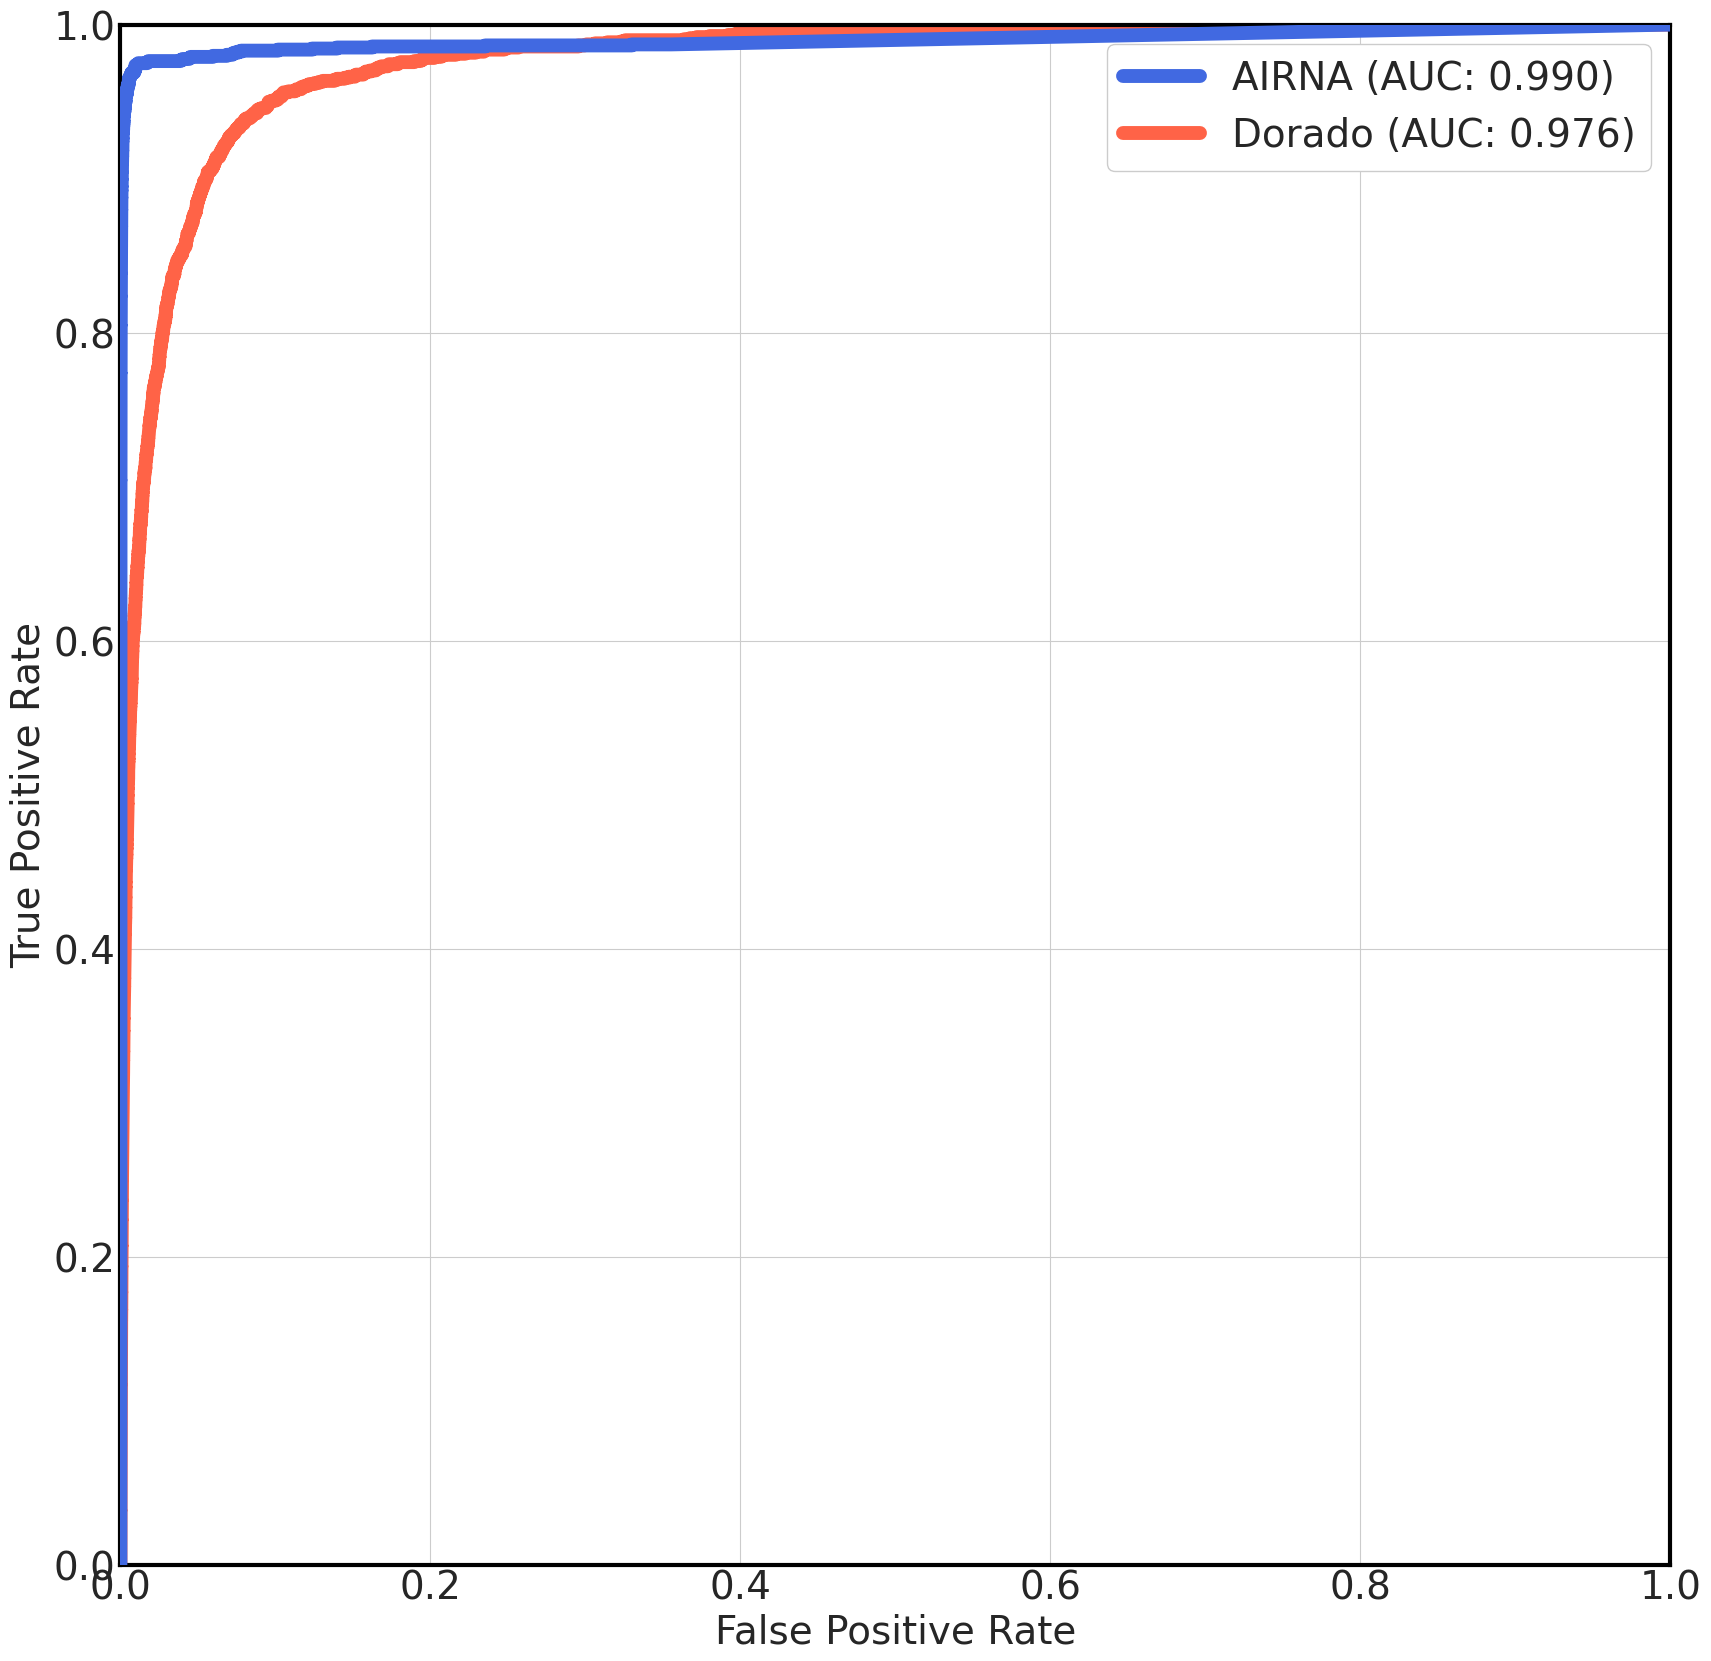

In [72]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = final_benchmark_df[~final_benchmark_df["drach"].fillna(0)].fillna(0)
selected_df = selected_df[selected_df["depth"] >= 100].copy()

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)


## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_roc.pdf", format="pdf")
plt.show()

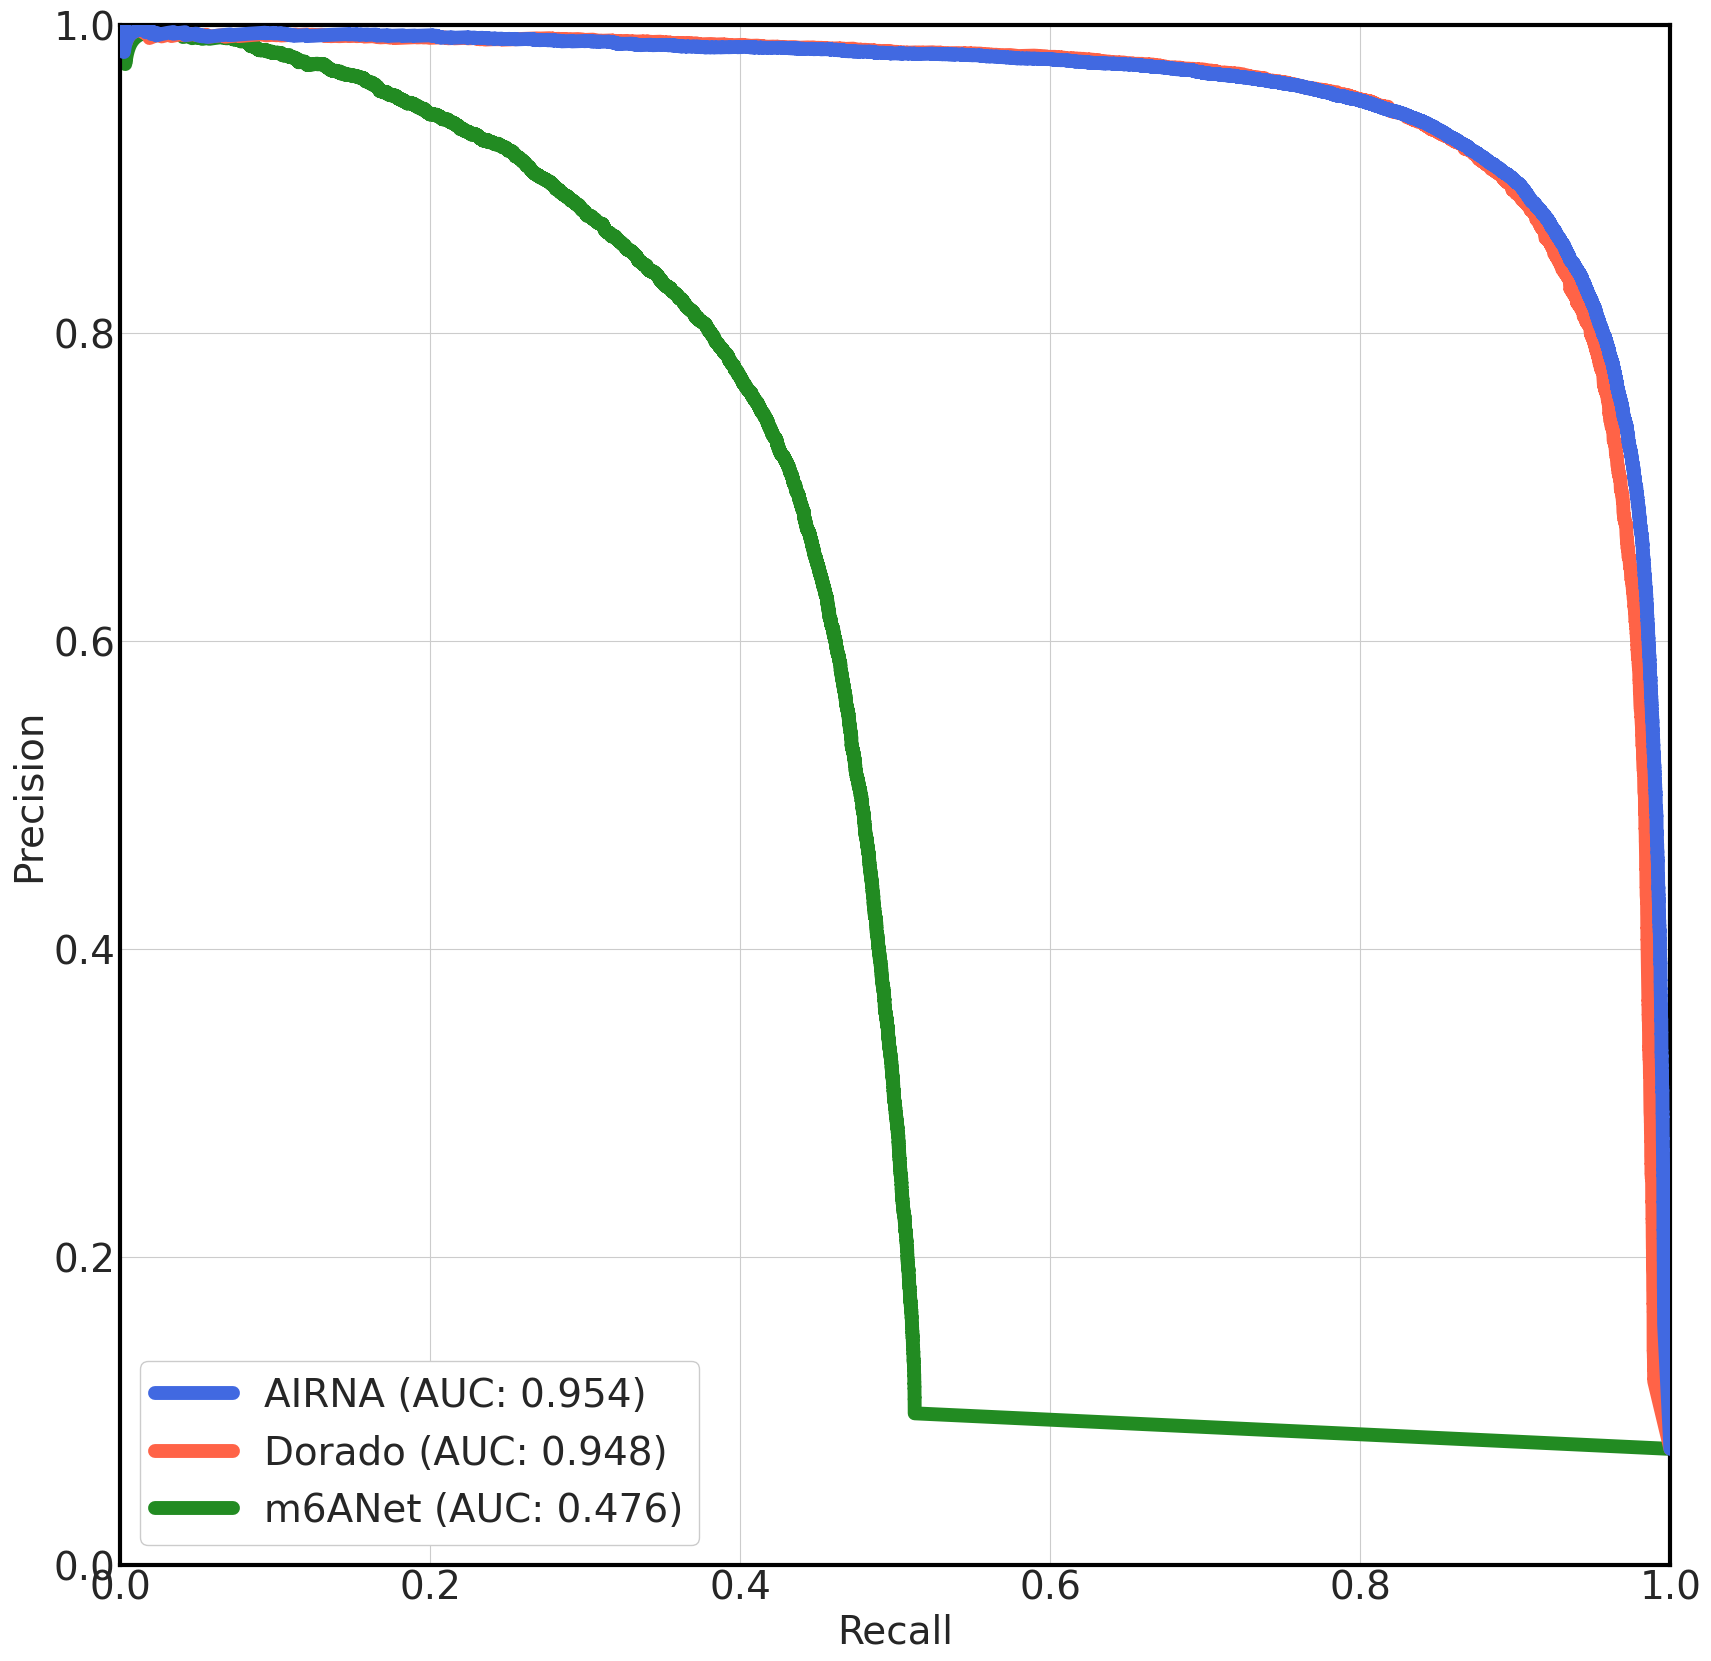

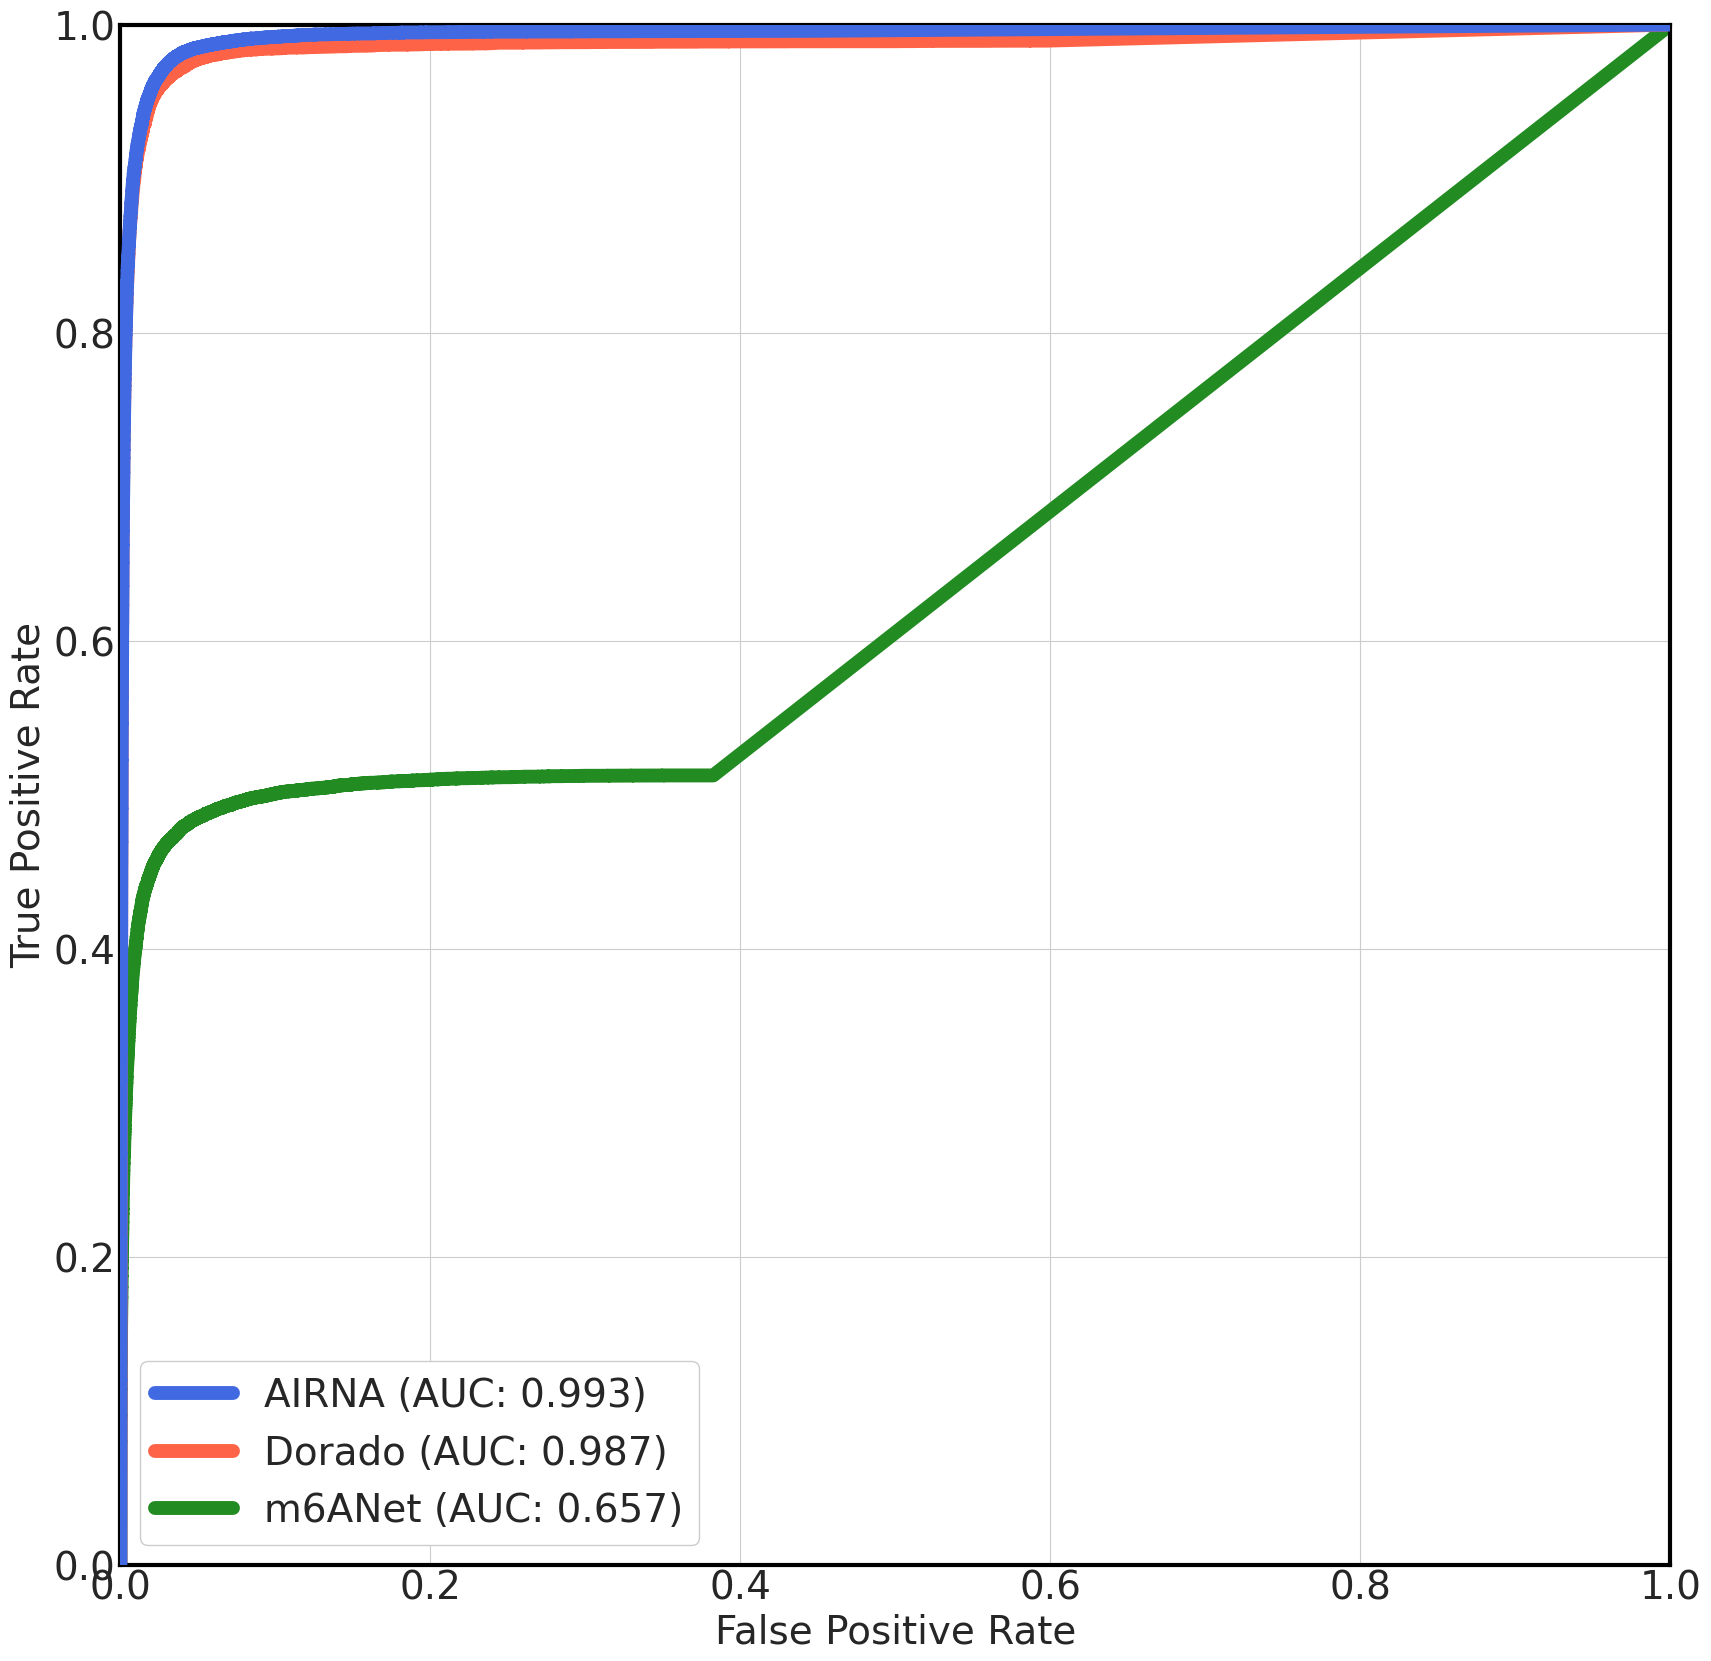

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = final_benchmark_df[final_benchmark_df["drach"].fillna(0)].fillna(0).copy()
selected_df["pm6a"] = selected_df["pm6a"] * (selected_df["count_all"]>=20)
selected_df["pred_dorado"] = selected_df["pred_dorado"] * (selected_df["count_dorado"]>=20)
selected_df["pred_m6anet"] = selected_df["pred_m6anet"] * (selected_df["count_m6anet"]>=20)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
# plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_roc.pdf", format="pdf")
plt.show()


In [74]:

selected_df = final_benchmark_df.fillna(0)

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
threshold = thresholds[f1_argmax]

print(f"AIRNA Max F1: {max_f1:.3f}, Threshold: {threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")


precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"Dorado Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"m6Anet Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

AIRNA Max F1: 0.882, Threshold: 0.793, Recall: 0.884, Precision: 0.880
Dorado Max F1: 0.590, Threshold: 0.501, Recall: 0.560, Precision: 0.624
m6Anet Max F1: 0.510, Threshold: 0.571, Recall: 0.397, Precision: 0.713
